# Venn Diagram Set-Intersection Analysis

Venn diagrams represent set overlaps and intersections. In business analytics, Venn diagrams visualize customer overlap segments subscribing to multiple products (e.g. streaming services: Video, Music, Games). This notebook models customer subscription overlaps across 3 packages (Total = 1,000 customers) and builds a clean Venn layout using intersecting Matplotlib circular patch shapes.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define subscription categories (Video, Music, Games)
# Total customers = 1000
n_total = 1000

# Overlaps counts (7 distinct regions):
# A only, B only, C only, A&B, A&C, B&C, A&B&C
set_counts = {
    'Video_Only': 420,
    'Music_Only': 190,
    'Games_Only': 110,
    'Video_and_Music': 85,
    'Video_and_Games': 45,
    'Music_and_Games': 22,
    'All_Three': 128 # 12.8% intersection rate
}

df_sets = pd.DataFrame(list(set_counts.items()), columns=['Segment', 'Count'])
df_sets['Percentage'] = df_sets['Count'] / n_total * 100
df_sets



,Segment,Count,Percentage
0,Video_Only,420,42.0
1,Music_Only,190,19.0
2,Games_Only,110,11.0
3,Video_and_Music,85,8.5
4,Video_and_Games,45,4.5
5,Music_and_Games,22,2.2
6,All_Three,128,12.8


## Set Theory Intersections

We sum subscription sizes across the three categories to check cardinalities.



In [2]:
video_total = set_counts['Video_Only'] + set_counts['Video_and_Music'] + set_counts['Video_and_Games'] + set_counts['All_Three']
music_total = set_counts['Music_Only'] + set_counts['Video_and_Music'] + set_counts['Music_and_Games'] + set_counts['All_Three']
games_total = set_counts['Games_Only'] + set_counts['Video_and_Games'] + set_counts['Music_and_Games'] + set_counts['All_Three']

print(f"Total Video Subscribers: {video_total}")
print(f"Total Music Subscribers: {music_total}")
print(f"Total Games Subscribers: {games_total}")



Total Video Subscribers: 678
Total Music Subscribers: 425
Total Games Subscribers: 305


## Overlapping Circular Patch Venn Diagram

Using Matplotlib patches, we draw three circles offset from each other with transparent colors, adding center annotations to label counts.



<cell>:48: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



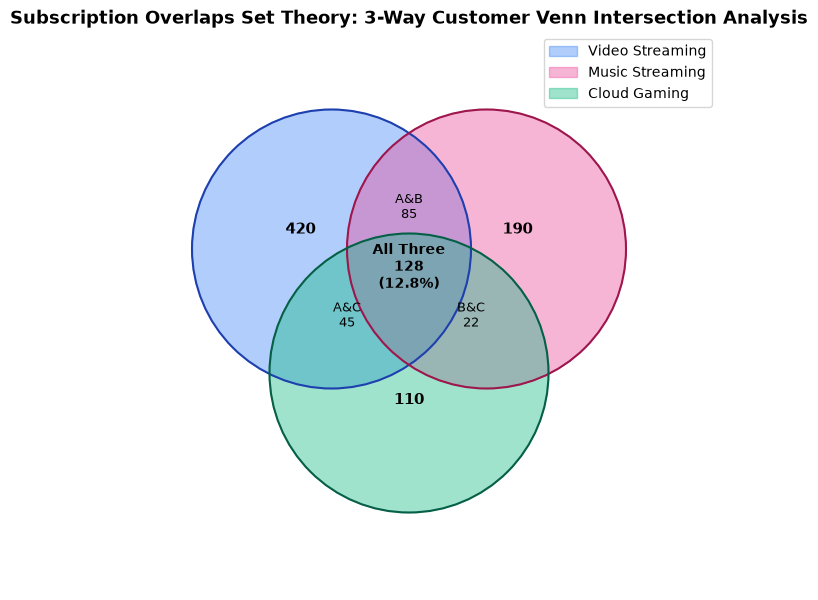

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))

# Define center coordinates and radii for the three circles
# Circle A: Video (Top-Left)
c_a = (-0.5, 0.4)
# Circle B: Music (Top-Right)
c_b = (0.5, 0.4)
# Circle C: Games (Bottom-Center)
c_c = (0.0, -0.4)

r = 0.9

# Draw filled circles
circle_a = patches.Circle(c_a, r, color='#3B82F6', alpha=0.4, label='Video Streaming')
circle_b = patches.Circle(c_b, r, color='#EC4899', alpha=0.4, label='Music Streaming')
circle_c = patches.Circle(c_c, r, color='#10B981', alpha=0.4, label='Cloud Gaming')

ax.add_patch(circle_a)
ax.add_patch(circle_b)
ax.add_patch(circle_c)

# Draw circle outlines
ax.add_patch(patches.Circle(c_a, r, fill=False, edgecolor='#1E40AF', linewidth=1.5))
ax.add_patch(patches.Circle(c_b, r, fill=False, edgecolor='#9D174D', linewidth=1.5))
ax.add_patch(patches.Circle(c_c, r, fill=False, edgecolor='#065F46', linewidth=1.5))

# Annotate counts inside overlap zones
# A only, B only, C only
ax.text(-0.7, 0.5, f"{set_counts['Video_Only']}", fontsize=11, fontweight='bold', ha='center')
ax.text(0.7, 0.5, f"{set_counts['Music_Only']}", fontsize=11, fontweight='bold', ha='center')
ax.text(0.0, -0.6, f"{set_counts['Games_Only']}", fontsize=11, fontweight='bold', ha='center')

# A&B, A&C, B&C
ax.text(0.0, 0.6, f"A&B\n{set_counts['Video_and_Music']}", fontsize=9, ha='center')
ax.text(-0.4, -0.1, f"A&C\n{set_counts['Video_and_Games']}", fontsize=9, ha='center')
ax.text(0.4, -0.1, f"B&C\n{set_counts['Music_and_Games']}", fontsize=9, ha='center')

# All three intersection
ax.text(0.0, 0.15, f"All Three\n{set_counts['All_Three']}\n(12.8%)", fontsize=10, fontweight='bold', ha='center')

ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-1.8, 1.8)
ax.set_aspect('equal')
ax.axis('off')

plt.title('Subscription Overlaps Set Theory: 3-Way Customer Venn Intersection Analysis', fontsize=13, fontweight='bold')
plt.legend(loc='upper right')
plt.show()
